# Notebook 2: Simulation & Quantum Volume Estimation
**Paper 5 – Cross-Framework Quantum Algorithm Benchmarking**

**Purpose**: Simulate all compiled QASM files using the QSim Cirq backend
and compute estimated Quantum Volume per circuit.

**Prerequisites**: Run `nb01_compile_and_static_analysis.ipynb` first.

**Outputs**:
- `benchmarks/metrics/simulation_metrics.csv`
- `benchmarks/metrics/distributions/*.json`
- `benchmarks/metrics/quantum_volume_estimates.csv`

**Pipeline step**: Step 2 of 5

In [1]:
import os, sys
QCANVAS_ROOT = os.path.abspath('../..')
if QCANVAS_ROOT not in sys.path:
    sys.path.insert(0, QCANVAS_ROOT)
import pandas as pd
import matplotlib.pyplot as plt
from benchmarks.scripts.figure_styles import apply_paper_style, save_figure, FRAMEWORK_COLORS, FRAMEWORK_LABELS

In [2]:
# ── Phase 3: Simulate all QASM files ────────────────────────────────────────
from benchmarks.scripts.simulate_all import run_all_simulations

print('Running simulations (QSim Cirq backend — ALL frameworks)...')
df_sim = run_all_simulations(n_repeats=10, shot_counts=[1024, 4096, 8192], verbose=True)
df_sim.to_csv('../metrics/simulation_metrics.csv', index=False)
print(f'\nSimulation complete: {len(df_sim)} rows saved.')

Running simulations (QSim Cirq backend — ALL frameworks)...
  Simulating: [1/405] bell_state (2q) cirq @ 1024 shots … ✓  82.5 ± 30.9 ms  |  mem=0.3 MB
  Simulating: [2/405] bell_state (2q) cirq @ 4096 shots … ✓  271.2 ± 24.5 ms  |  mem=0.7 MB
  Simulating: [3/405] bell_state (2q) cirq @ 8192 shots … ✓  558.7 ± 135.1 ms  |  mem=1.3 MB
  Simulating: [4/405] bell_state (2q) pennylane @ 1024 shots … ✓  80.0 ± 10.0 ms  |  mem=0.2 MB
  Simulating: [5/405] bell_state (2q) pennylane @ 4096 shots … ✓  274.7 ± 10.1 ms  |  mem=0.7 MB
  Simulating: [6/405] bell_state (2q) pennylane @ 8192 shots … ✓  629.7 ± 108.4 ms  |  mem=1.3 MB
  Simulating: [7/405] bell_state (2q) qiskit @ 1024 shots … ✓  106.7 ± 13.2 ms  |  mem=0.2 MB
  Simulating: [8/405] bell_state (2q) qiskit @ 4096 shots … ✓  278.6 ± 15.5 ms  |  mem=0.7 MB
  Simulating: [9/405] bell_state (2q) qiskit @ 8192 shots … ✓  528.1 ± 40.4 ms  |  mem=1.3 MB
  Simulating: [10/405] bernstein_vazirani (3q) cirq @ 1024 shots … ✓  109.7 ± 3.4 ms  |  me

In [3]:
# ── Simulation timing summary ────────────────────────────────────────────────
df_sim = pd.read_csv('../metrics/simulation_metrics.csv')
df_4k  = df_sim[(df_sim['shots'] == 4096) & df_sim['success']]

print('Mean simulation time @ 4096 shots per framework (ms):')
print(df_4k.groupby('framework')[['mean_sim_time_ms', 'std_sim_time_ms',
                                    'mean_memory_mb']].mean().round(2))

Mean simulation time @ 4096 shots per framework (ms):
           mean_sim_time_ms  std_sim_time_ms  mean_memory_mb
framework                                                   
cirq                 332.24            14.52            0.76
pennylane            517.78            24.03            1.00
qiskit               334.64            17.96            0.75


C:\Users\muham\AppData\Local\Temp\ipykernel_22752\2806641904.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_fw, labels=[FRAMEWORK_LABELS[fw] for fw in ['qiskit', 'cirq', 'pennylane']],


[save_figure] Saved: fig06_compilation_time_boxplot.pdf / .png → benchmarks\results\simulation/


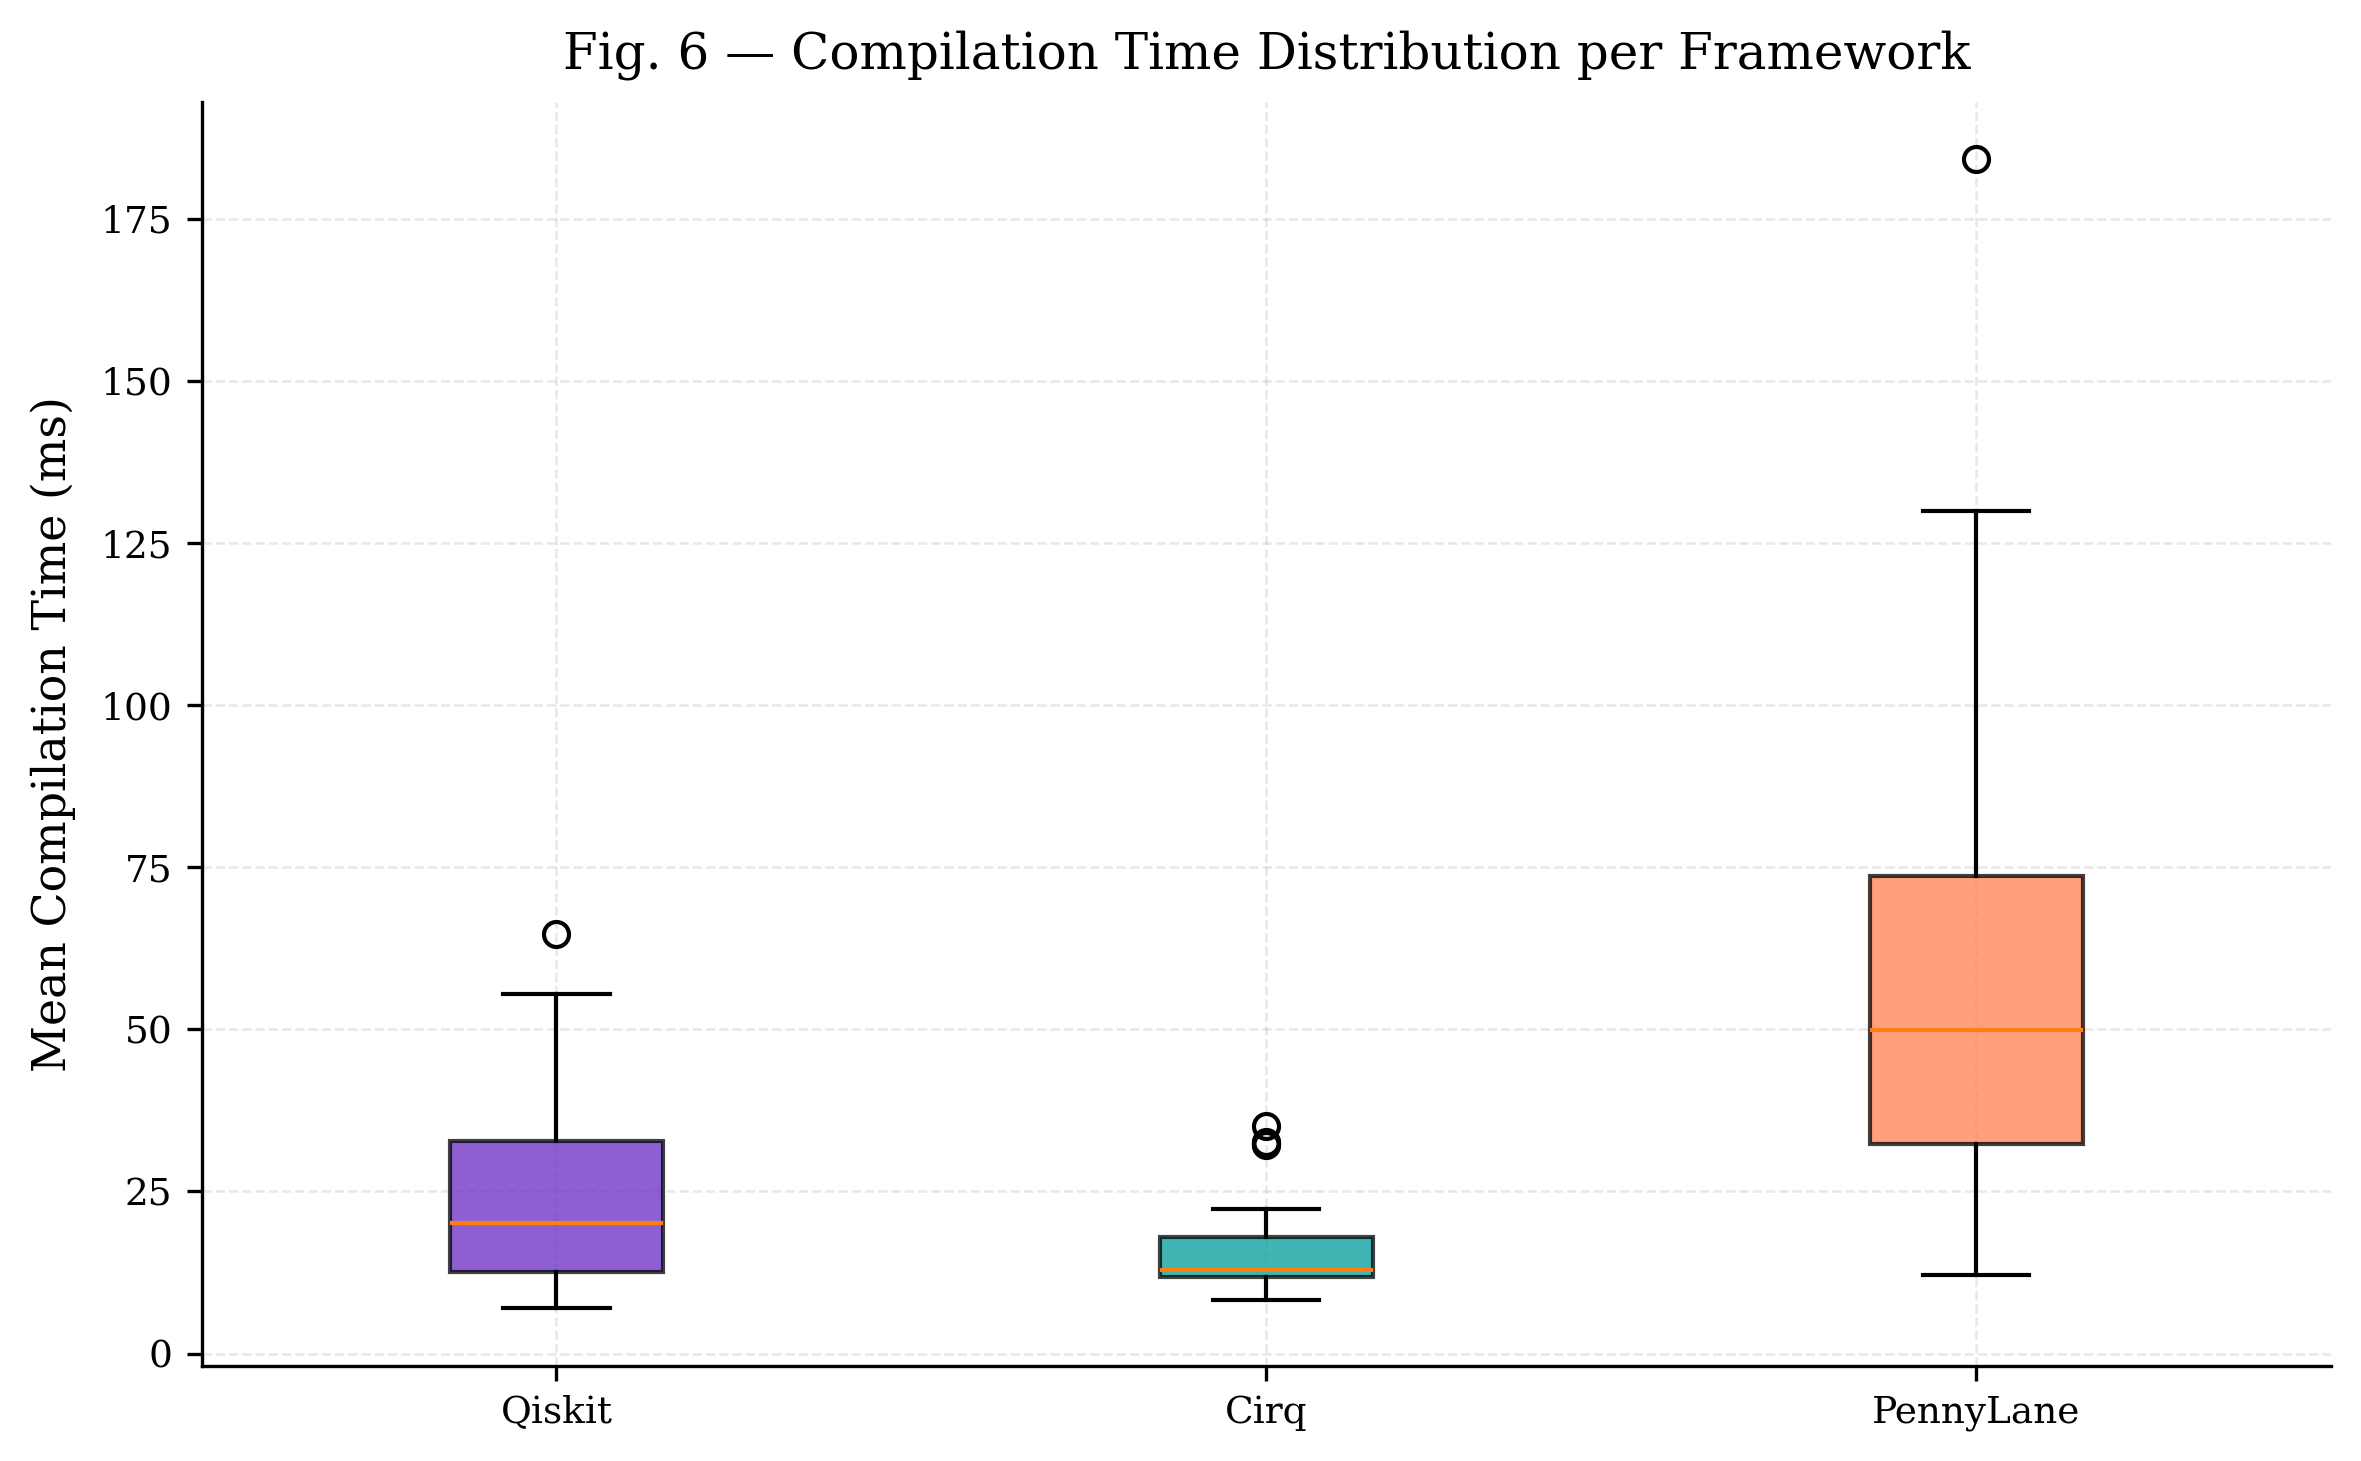

In [4]:
# ── Fig. 6: Compilation time box plots ──────────────────────────────────────
df_ctimes = pd.read_csv('../metrics/compilation_times.csv')
df_ctimes = df_ctimes[df_ctimes['success']]

apply_paper_style()
fig, ax = plt.subplots(figsize=(8, 5))
data_by_fw = [df_ctimes[df_ctimes['framework'] == fw]['mean_compile_ms'].values
              for fw in ['qiskit', 'cirq', 'pennylane']]
bp = ax.boxplot(data_by_fw, labels=[FRAMEWORK_LABELS[fw] for fw in ['qiskit', 'cirq', 'pennylane']],
                patch_artist=True)
for patch, fw in zip(bp['boxes'], ['qiskit', 'cirq', 'pennylane']):
    patch.set_facecolor(FRAMEWORK_COLORS[fw])
    patch.set_alpha(0.75)
ax.set_title('Fig. 6 — Compilation Time Distribution per Framework')
ax.set_ylabel('Mean Compilation Time (ms)')
plt.tight_layout()
save_figure(fig, 'fig06_compilation_time_boxplot', 'simulation')
plt.show()

C:\Users\muham\AppData\Local\Temp\ipykernel_22752\120869585.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_fw, labels=[FRAMEWORK_LABELS[fw] for fw in ['qiskit', 'cirq', 'pennylane']],


[save_figure] Saved: fig07_simulation_time_boxplot.pdf / .png → benchmarks\results\simulation/


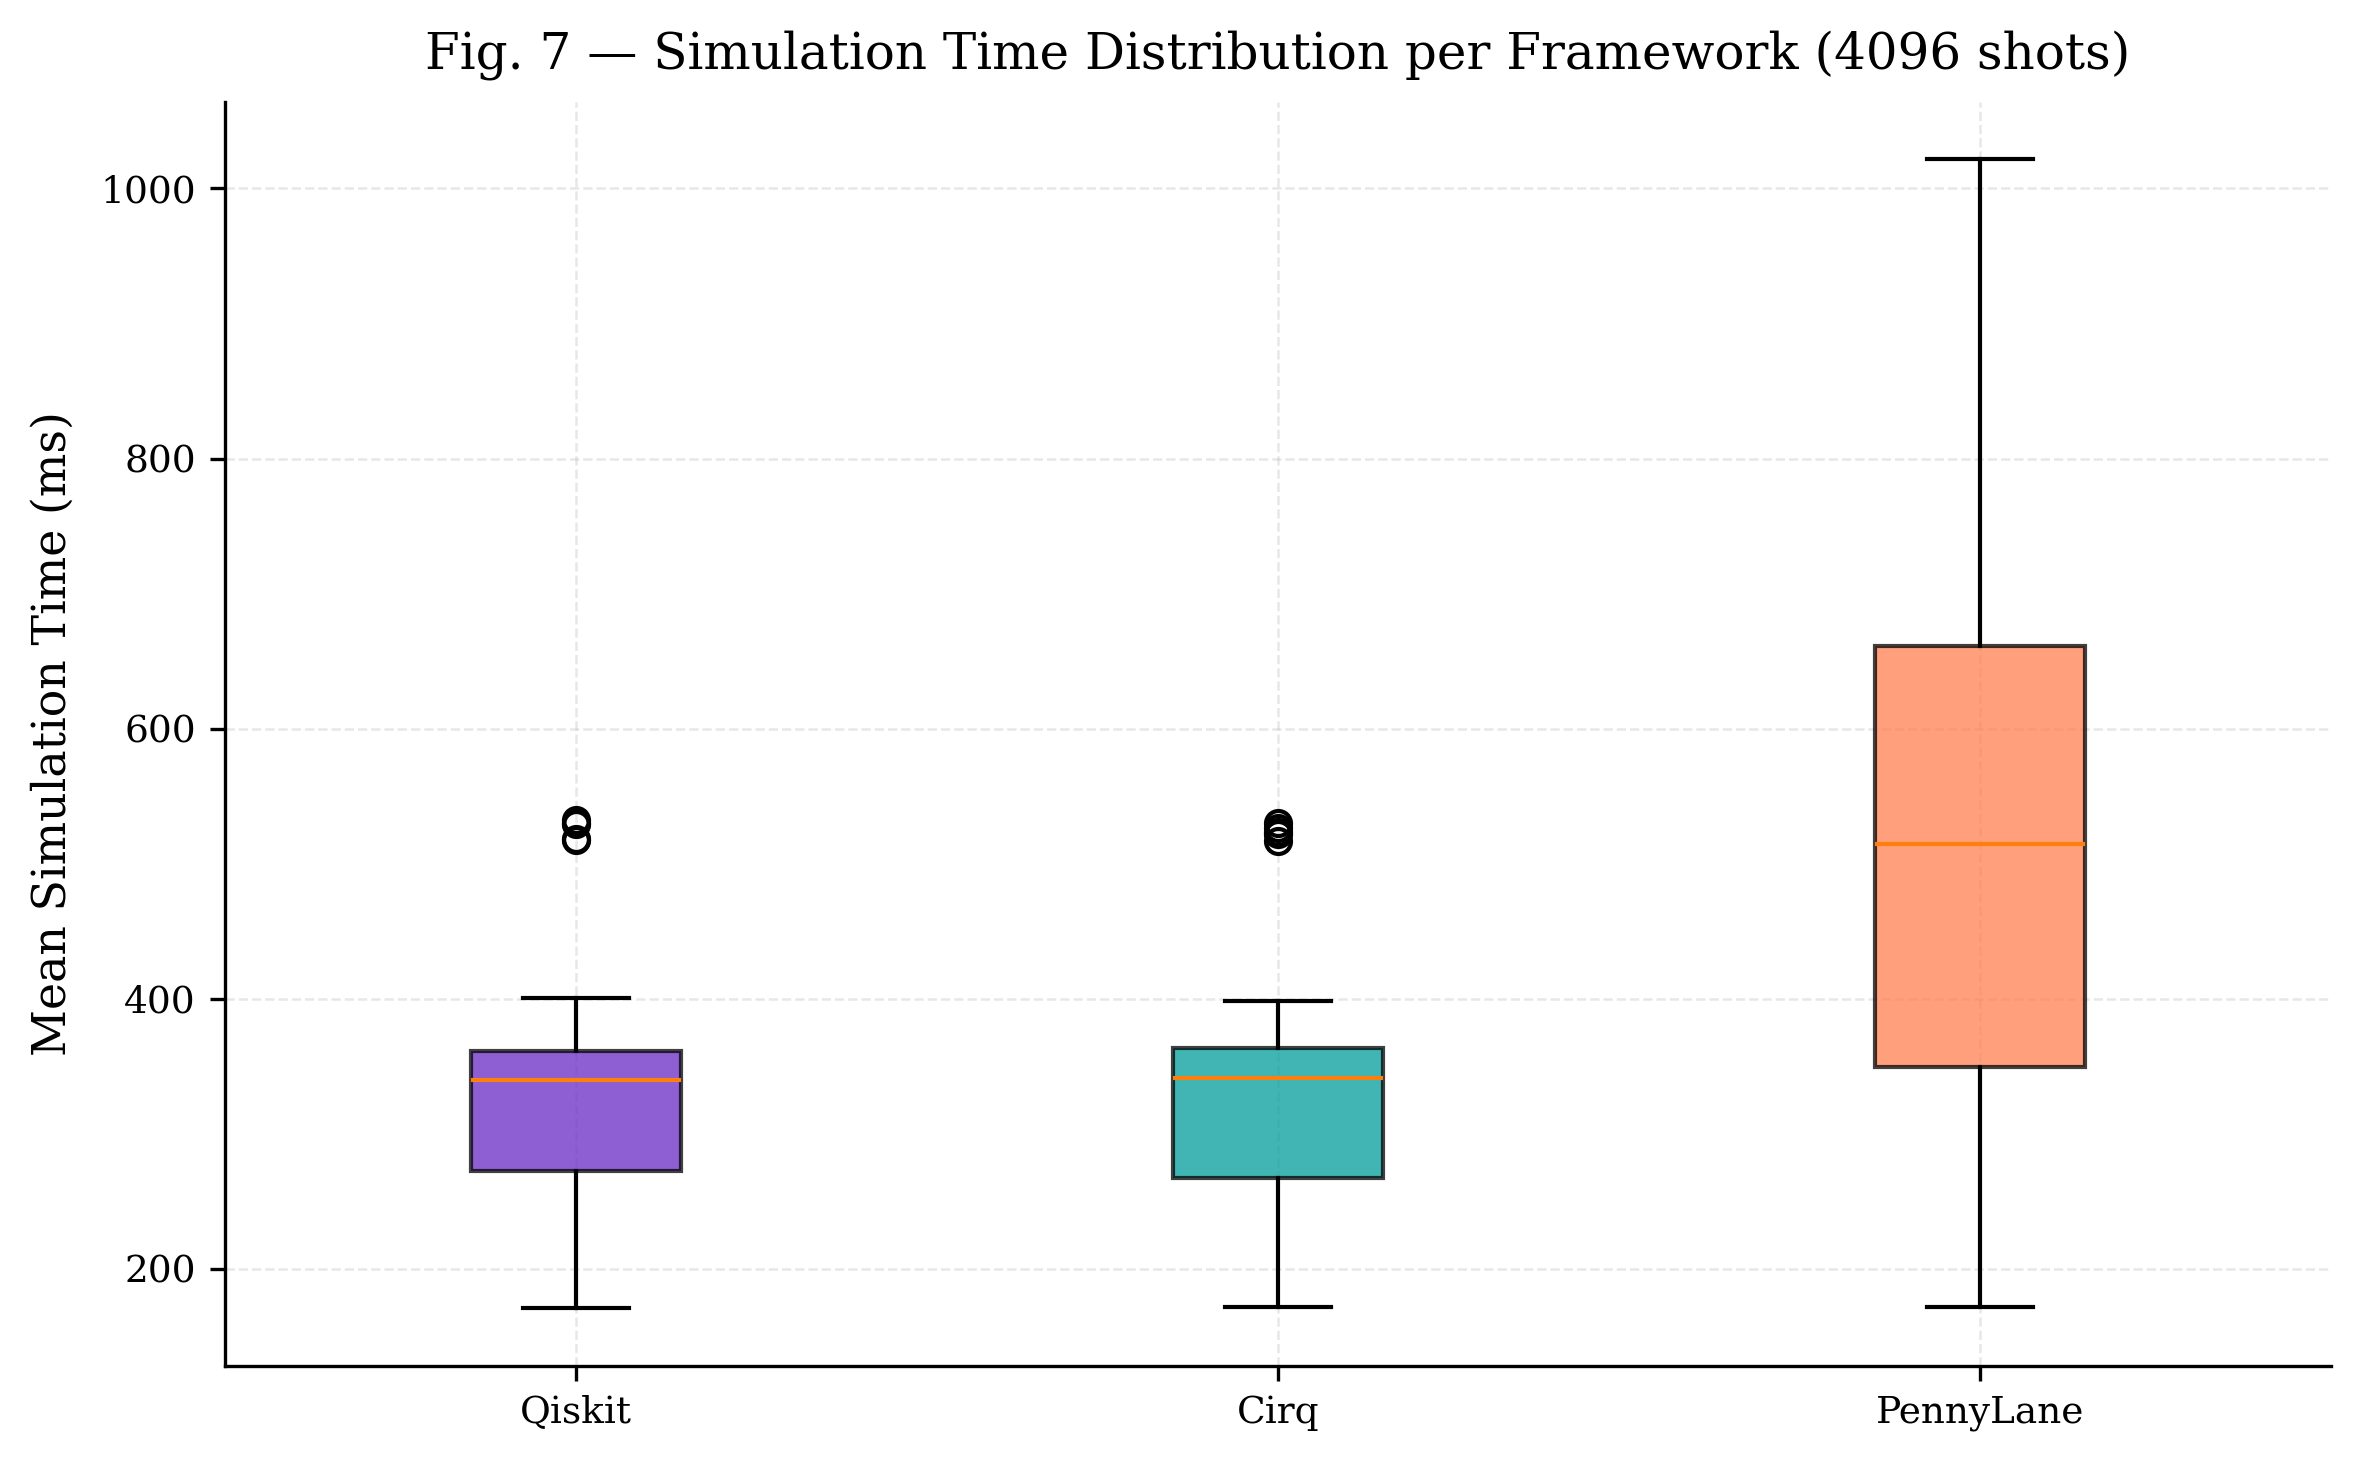

In [5]:
# ── Fig. 7: Simulation time box plots ───────────────────────────────────────
apply_paper_style()
fig, ax = plt.subplots(figsize=(8, 5))
data_by_fw = [df_4k[df_4k['framework'] == fw]['mean_sim_time_ms'].values
              for fw in ['qiskit', 'cirq', 'pennylane']]
bp = ax.boxplot(data_by_fw, labels=[FRAMEWORK_LABELS[fw] for fw in ['qiskit', 'cirq', 'pennylane']],
                patch_artist=True)
for patch, fw in zip(bp['boxes'], ['qiskit', 'cirq', 'pennylane']):
    patch.set_facecolor(FRAMEWORK_COLORS[fw])
    patch.set_alpha(0.75)
ax.set_title('Fig. 7 — Simulation Time Distribution per Framework (4096 shots)')
ax.set_ylabel('Mean Simulation Time (ms)')
plt.tight_layout()
save_figure(fig, 'fig07_simulation_time_boxplot', 'simulation')
plt.show()

[save_figure] Saved: fig08_memory_usage.pdf / .png → benchmarks\results\simulation/


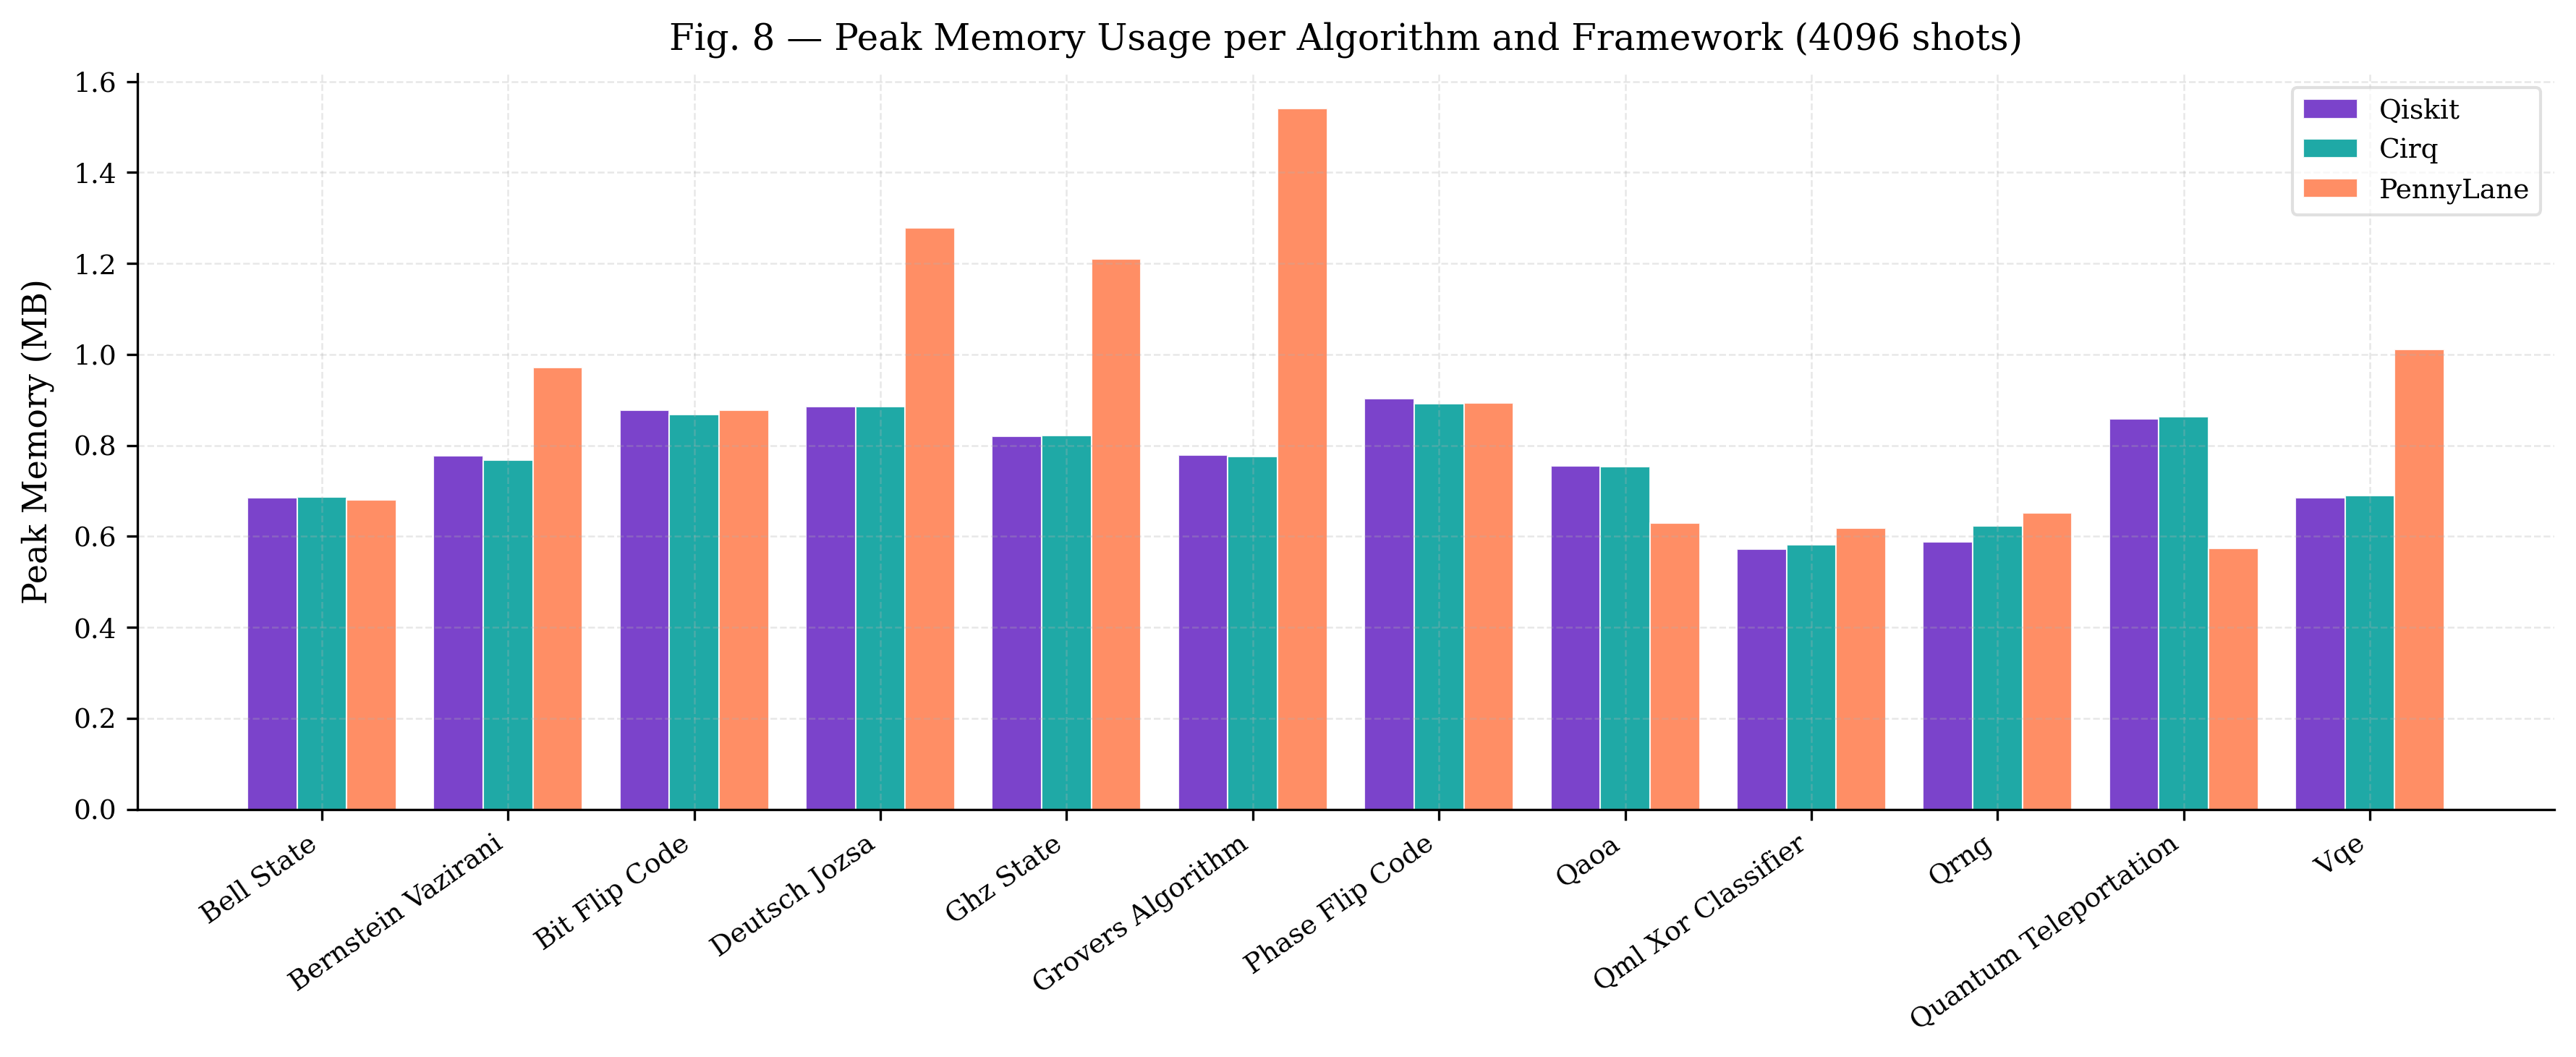

In [6]:
# ── Fig. 8: Memory usage per algorithm ──────────────────────────────────────
apply_paper_style()
from benchmarks.scripts.figure_styles import plot_grouped_bar

df_mem = df_4k.copy()
fig, ax = plt.subplots(figsize=(12, 5))
plot_grouped_bar(
    ax, df_mem,
    x_col='algorithm', y_col='mean_memory_mb',
    title='Fig. 8 — Peak Memory Usage per Algorithm and Framework (4096 shots)',
    ylabel='Peak Memory (MB)',
)
plt.tight_layout()
save_figure(fig, 'fig08_memory_usage', 'simulation')
plt.show()

In [7]:
# ── Phase: Quantum Volume estimation ────────────────────────────────────────
from benchmarks.scripts.quantum_volume import compute_qv_for_all

df_qv = compute_qv_for_all('../metrics/structural_metrics.csv')
df_qv.to_csv('../metrics/quantum_volume_estimates.csv', index=False)
print(f'QV estimates computed for {len(df_qv)} circuits.')

QV estimates computed for 135 circuits.


[save_figure] Saved: fig11_quantum_volume.pdf / .png → benchmarks\results\simulation/


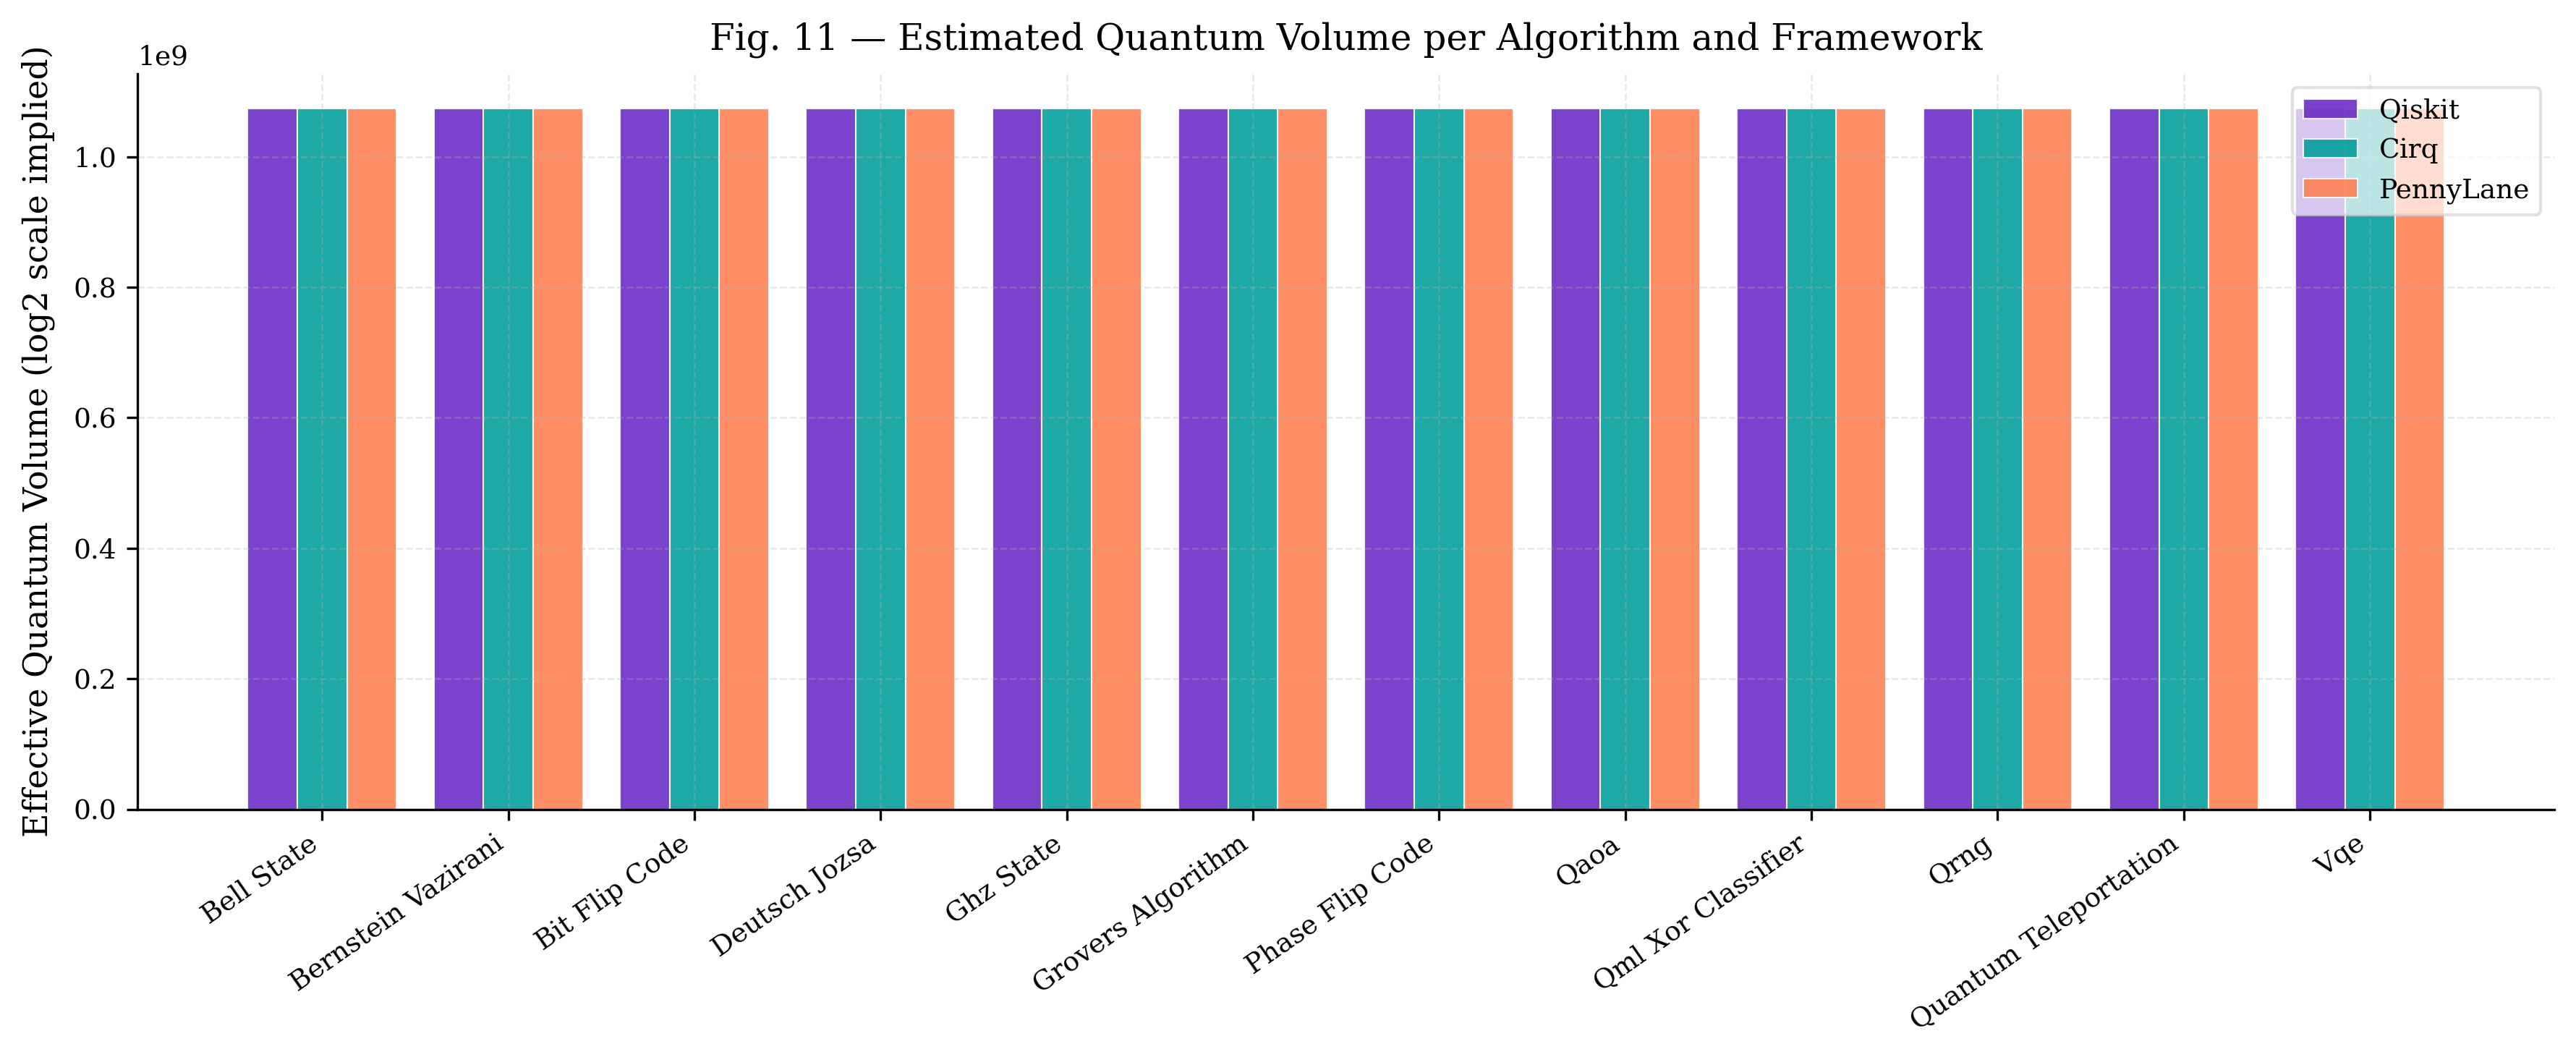

In [8]:
# ── Fig. 11: Quantum Volume per algorithm ────────────────────────────────────
apply_paper_style()
fig, ax = plt.subplots(figsize=(12, 5))

# Use minimum n_qubits per algorithm for consistent comparison
df_qv_fixed = df_qv[df_qv['n_qubits'] == df_qv.groupby('algorithm')['n_qubits'].transform('min')]
plot_grouped_bar(
    ax, df_qv_fixed,
    x_col='algorithm', y_col='effective_qv',
    title='Fig. 11 — Estimated Quantum Volume per Algorithm and Framework',
    ylabel='Effective Quantum Volume (log2 scale implied)',
)
plt.tight_layout()
save_figure(fig, 'fig11_quantum_volume', 'simulation')
plt.show()

[save_figure] Saved: fig12_qv_vs_depth.pdf / .png → benchmarks\results\simulation/


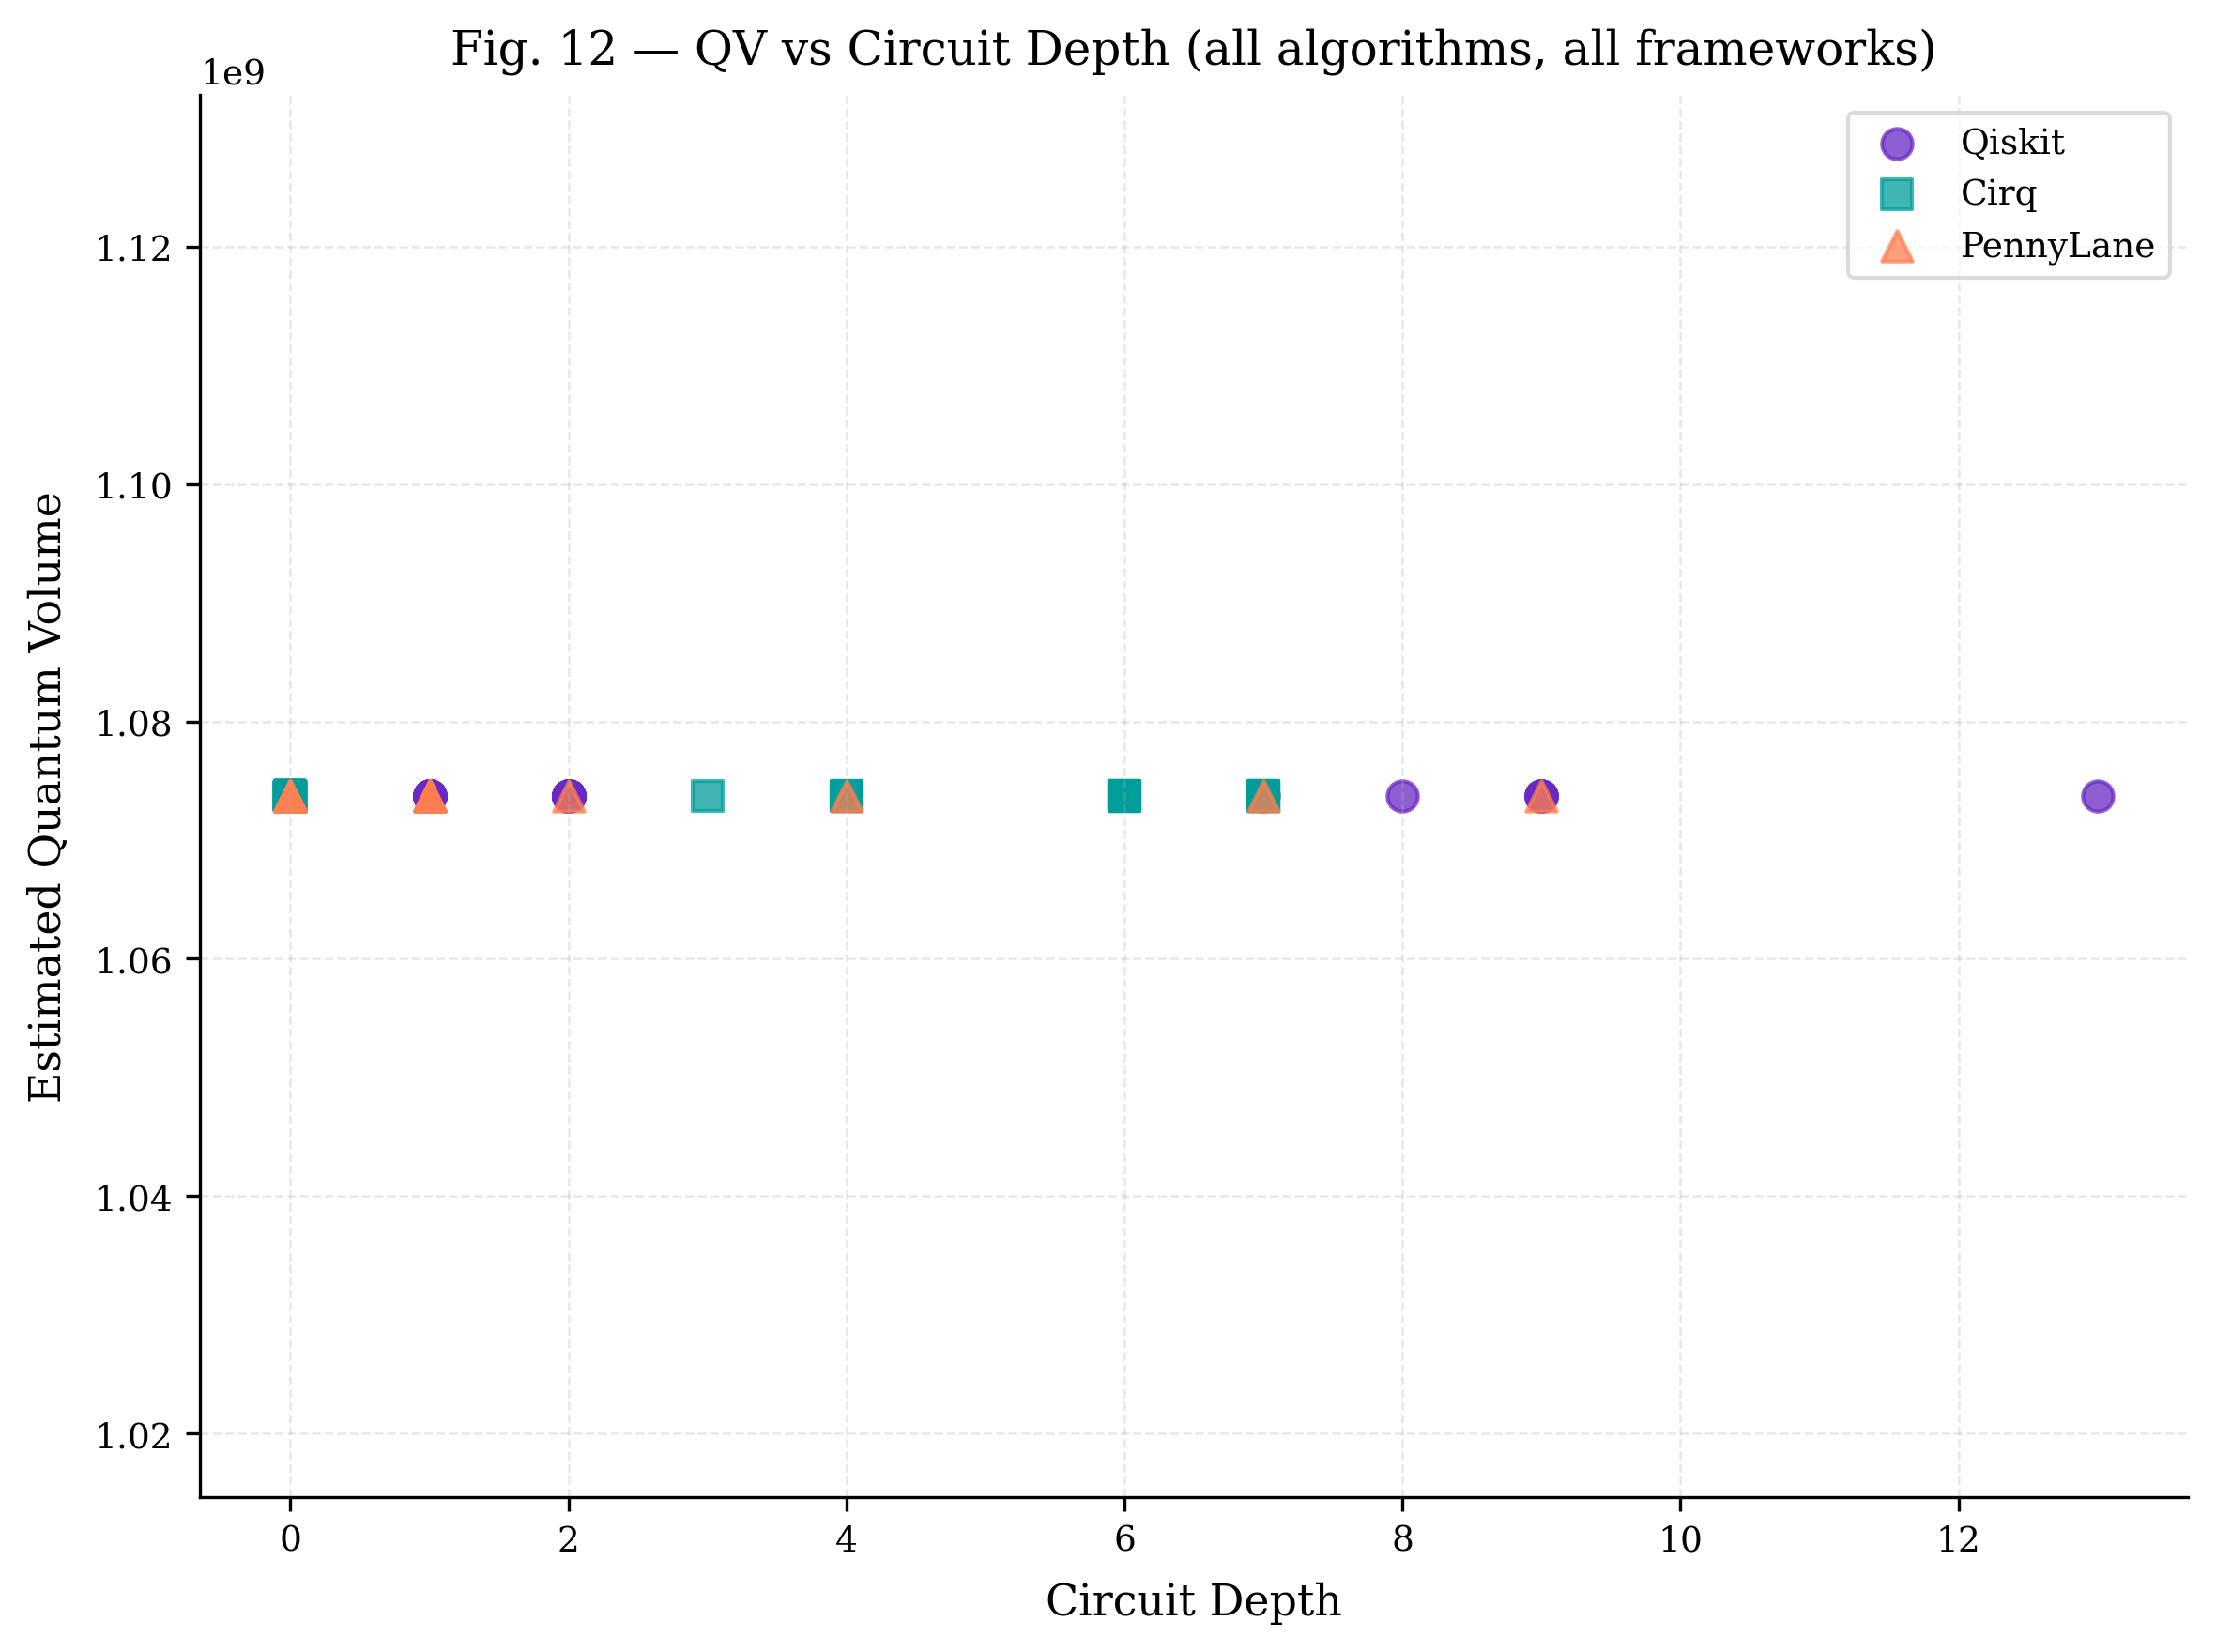

In [9]:
# ── Fig. 12: QV vs Circuit Depth scatter ────────────────────────────────────
apply_paper_style()
from benchmarks.scripts.figure_styles import FRAMEWORK_MARKERS

fig, ax = plt.subplots(figsize=(8, 6))
for fw in ['qiskit', 'cirq', 'pennylane']:
    sub = df_qv[df_qv['framework'] == fw]
    ax.scatter(sub['circuit_depth'], sub['effective_qv'],
               color=FRAMEWORK_COLORS[fw], marker=FRAMEWORK_MARKERS[fw],
               label=FRAMEWORK_LABELS[fw], alpha=0.75, s=60)

ax.set_xlabel('Circuit Depth')
ax.set_ylabel('Estimated Quantum Volume')
ax.set_title('Fig. 12 — QV vs Circuit Depth (all algorithms, all frameworks)')
ax.legend(framealpha=0.7)
plt.tight_layout()
save_figure(fig, 'fig12_qv_vs_depth', 'simulation')
plt.show()